In [1]:
import os, json, shutil, math
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd

import contextlib
from scipy.ndimage import affine_transform  
from scipy.ndimage import label as cc_label

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

SPLITS_DIR = Path(r"D:\master_experiments\data\splits\BraTS2020_Splits")
META_PATH  = SPLITS_DIR / "splits_metadata.json"

MOME_BASE = Path(r"D:\master_experiments\models_configs\MoME_BraTS2020")
MOME_CKPT = MOME_BASE / "checkpoints"
MOME_PRED = MOME_BASE / "predictions_test"
MOME_LOGS = MOME_BASE / "logs"

for p in [MOME_BASE, MOME_CKPT, MOME_PRED, MOME_LOGS]:
    p.mkdir(parents=True, exist_ok=True)

MODS      = ["flair", "t1", "t1ce", "t2"]
N_EXPERTS = len(MODS)  
N_CLASSES = 4           
DEPTH     = 3
BASE_CH   = 32
PATCH     = 128         
NUM_ITERS_PER_EPOCH = 250  

FILE_ENDING = ".nii.gz"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NW = 0 if os.name == "nt" else 4

print("Device:", DEVICE)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory/1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER | VRAM: 12.9 GB


In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids   = meta["ids"]["val"]
test_ids  = meta["ids"]["test"]

print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

Train: 245 | Val: 52 | Test: 53


In [3]:
def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1":
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def load_arr(p):
    return np.asanyarray(nib.load(str(p)).dataobj)

def norm01(x, p1=1, p99=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo), 0, 1)

def norm_zscore_fg(x): 
    x = x.astype(np.float32)
    mask = x > 0
    if mask.sum() == 0:
        return np.zeros_like(x, dtype=np.float32)
    mean = float(x[mask].mean())
    std  = float(x[mask].std()) + 1e-8
    out  = (x - mean) / std
    out[~mask] = 0.0 
    return out

def dice_score(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(seg, axis=2):
    counts = np.sum(seg > 0, axis=tuple(i for i in range(3) if i != axis))
    return int(np.argmax(counts))

def load_brats_seg(path):
    data = load_arr(path).astype(np.int16)
    data[data == 4] = 3
    return data

In [4]:
class BraTSPatchDataset(Dataset):

    def __init__(self, ids_list, split_name,
                 mode="all", mod_idx=None,
                 patch=PATCH, augment=True,
                 num_iterations=None): 
        assert mode in ("all", "single_expert")
        if mode == "single_expert":
            assert mod_idx is not None, \
                "mod_idx obrigatório para mode='single_expert'"
        self.ids     = ids_list
        self.split   = split_name
        self.mode    = mode
        self.mod_idx = mod_idx
        self.patch   = patch
        self.aug     = augment
        self.num_iterations = num_iterations 

    def __len__(self):
        return self.num_iterations if self.num_iterations is not None else len(self.ids)

    def _lesion_crop(self, arrays, patch):  
        seg = arrays[-1]
        if np.random.rand() < 0.33:
            coords = np.argwhere(seg > 0)
            if len(coords) == 0:
                coords = np.argwhere(np.ones_like(seg))
        else:
            coords = np.argwhere(np.ones_like(seg))
        center = coords[np.random.randint(len(coords))]
        half = patch // 2
        lo, hi = [], []
        for ax in range(3):
            c = int(np.clip(center[ax], half, seg.shape[ax] - half))
            lo.append(c - half)
            hi.append(c + half)
        return [a[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] for a in arrays]

    def _augment(self, imgs, seg):  
        if np.random.rand() < 0.2:
            angle = np.random.uniform(-30, 30) * np.pi / 180.0
            scale = np.random.uniform(0.85, 1.25)
            cos_a = np.cos(angle) / scale
            sin_a = np.sin(angle) / scale
            matrix = np.array([
                [1.0/scale, 0.0, 0.0],
                [0.0,  cos_a, sin_a],
                [0.0, -sin_a, cos_a],
            ], dtype=np.float64)
            shape = np.array(imgs[0].shape)
            center = (shape - 1) / 2.0
            offset = center - matrix @ center
            imgs = [affine_transform(im, matrix, offset=offset, order=1,
                                     mode='constant', cval=0).astype(np.float32) for im in imgs]
            seg  = affine_transform(seg.astype(np.int16), matrix, offset=offset, order=0,
                                    mode='constant', cval=0).astype(np.int16)

        for ax in range(3):
            if np.random.rand() > 0.5:
                imgs = [np.flip(im, axis=ax).copy() for im in imgs]
                seg  = np.flip(seg, axis=ax).copy()

        bright = np.random.uniform(0.85, 1.15) if np.random.rand() > 0.5 else 1.0
        aug_imgs = []
        for im in imgs:
            im = im * bright
            if np.random.rand() > 0.5:
                im = im + np.random.normal(0, 0.05, im.shape).astype(np.float32)
            aug_imgs.append(im.astype(np.float32))
        return aug_imgs, seg

    def __getitem__(self, idx):
        if self.num_iterations is not None:
            cid = self.ids[np.random.randint(len(self.ids))]
        else:
            cid = self.ids[idx]
        d = case_dir(self.split, cid)

        imgs = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]  
        seg  = load_brats_seg(find_file(d, "seg"))

        cropped   = self._lesion_crop(imgs + [seg], self.patch)
        imgs, seg = cropped[:-1], cropped[-1]

        if self.aug:
            imgs, seg = self._augment(imgs, seg)

        seg_t = torch.from_numpy(seg.astype(np.int64)) 

        if self.mode == "all":
            vol = torch.from_numpy(
                np.stack(imgs, axis=0).astype(np.float32))  
            return vol, seg_t

        vol = torch.from_numpy(
            imgs[self.mod_idx][None].astype(np.float32)) 
        return vol, seg_t

In [5]:
def double_conv(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm3d(out_ch),
        nn.LeakyReLU(0.01, inplace=True),
        nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm3d(out_ch),
        nn.LeakyReLU(0.01, inplace=True),
    )


class ExpertUNet(nn.Module):
    def __init__(self, n_cls, base_ch=BASE_CH, depth=DEPTH):
        super().__init__()
        self.depth = depth
        chs = [base_ch * (2 ** i) for i in range(depth + 1)]

        self.enc  = nn.ModuleList()
        self.pool = nn.ModuleList()
        ch_in = 1
        for i in range(depth):
            self.enc.append(double_conv(ch_in, chs[i]))
            self.pool.append(nn.MaxPool3d(2))
            ch_in = chs[i]

        self.bn = double_conv(ch_in, chs[depth])

        self.up   = nn.ModuleList()
        self.dec  = nn.ModuleList()
        self.head = nn.ModuleList()
        for i in range(depth - 1, -1, -1):
            self.up.append(nn.ConvTranspose3d(chs[i+1], chs[i], 2, stride=2))
            self.dec.append(double_conv(chs[i] * 2, chs[i]))
            self.head.append(nn.Conv3d(chs[i], n_cls, 1))

        self.feat_chs = [base_ch * (2 ** i) for i in range(depth)]

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.enc, self.pool):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bn(x)

        logits_list, feat_list = [], []
        for i, (up, dec, head) in enumerate(
                zip(self.up, self.dec, self.head)):
            x = up(x)
            x = dec(torch.cat([skips[-(i+1)], x], dim=1))
            feat_list.append(x)
            logits_list.append(head(x))

        return logits_list[::-1], feat_list[::-1]


class GatingNetwork(nn.Module):

    def __init__(self, n_experts, feat_chs_per_level, gate_ch=16):
        super().__init__()
        self.n_experts = n_experts
        self.heads = nn.ModuleList()

        for ch in feat_chs_per_level:
            in_ch = ch * n_experts
            self.heads.append(nn.Sequential(
                nn.Conv3d(in_ch, gate_ch, 3, padding=1, bias=False),
                nn.InstanceNorm3d(gate_ch),
                nn.LeakyReLU(0.01, inplace=True),
                nn.Conv3d(gate_ch, n_experts, 1),
            ))

    def forward(self, feat_lists):
        n_levels  = len(feat_lists[0])
        gate_maps = []
        for lvl in range(n_levels):
            cat   = torch.cat([feat_lists[i][lvl]
                               for i in range(self.n_experts)], dim=1)
            raw   = self.heads[lvl](cat)
            gates = torch.softmax(raw, dim=1)
            gate_maps.append(gates)
        return gate_maps


class MoME(nn.Module):
    def __init__(self, n_experts=N_EXPERTS, n_cls=N_CLASSES,
                 base_ch=BASE_CH, depth=DEPTH):
        super().__init__()
        self.n_experts = n_experts
        self.depth     = depth
        self.n_levels  = depth

        self.experts = nn.ModuleList([
            ExpertUNet(n_cls, base_ch, depth)
            for _ in range(n_experts)
        ])

        feat_chs = self.experts[0].feat_chs
        self.gating = GatingNetwork(n_experts, feat_chs, gate_ch=16)

    def forward(self, x, mode="mome", i_expert=None):
        if mode == "expert":
            assert i_expert is not None
            assert x.shape[1] == 1, \
                "mode='expert' espera tensor [B,1,D,H,W]"
            logits, _ = self.experts[i_expert](x)
            return logits

        all_logits = []
        all_feats  = []

        for i in range(self.n_experts):
            xi = x[:, i:i+1]            
            logits, feats = self.experts[i](xi)
            all_logits.append(logits)
            all_feats.append(feats)

        gate_maps = self.gating(all_feats)  

        ensemble_logits = []
        for lvl in range(self.n_levels):
            o = sum(
                all_logits[i][lvl] * gate_maps[lvl][:, i:i+1]
                for i in range(self.n_experts)
            )
            ensemble_logits.append(o)

        return ensemble_logits, all_logits

In [6]:
class DeepSupervisionLoss(nn.Module):

    def __init__(self, n_levels=DEPTH):
        super().__init__()
        raw = [1.0 / (2 ** l) for l in range(n_levels)]
        s   = sum(raw)
        self.weights  = [w / s for w in raw]
        self.n_levels = n_levels

    def soft_dice(self, pred_soft, target_oh):

        smooth = 1e-5
        dims   = (0, 2, 3, 4)
        p = pred_soft[:, 1:]
        t = target_oh[:, 1:]
        inter = (p * t).sum(dims)
        denom = p.sum(dims) + t.sum(dims)
        return 1.0 - ((2.0 * inter + smooth) / (denom + smooth)).mean()

    def forward(self, logits_list, target):
        total = 0.0
        for lvl in range(self.n_levels):
            logits = logits_list[lvl]
            w      = self.weights[lvl]

            if lvl == 0:
                tgt = target
            else:
                scale = 1.0 / (2 ** lvl)
                tgt = F.interpolate(
                    target.float().unsqueeze(1),
                    scale_factor=scale, mode="nearest"
                ).squeeze(1).long()

            n_cls = logits.shape[1]
            oh    = F.one_hot(tgt, n_cls).permute(0, 4, 1, 2, 3).float()
            soft  = torch.softmax(logits, dim=1)

            loss_dice = self.soft_dice(soft, oh)
            loss_ce   = F.cross_entropy(logits, tgt)
            total    += w * (loss_dice + loss_ce)

        return total

In [7]:
def curriculum_weight(epoch_cur: int, epoch_total: int) -> float:
    if epoch_total <= 1:
        return 0.0
    return (1.0 - epoch_cur / (epoch_total - 1)) ** 2

In [8]:
def save_expert_ckpt(model: MoME, mod_idx: int, save_dir: Path):
    state = {"expert": model.experts[mod_idx].state_dict()}
    torch.save(state, save_dir / f"expert_{mod_idx}_{MODS[mod_idx]}.pth")

def load_all_expert_ckpts(model: MoME, save_dir: Path):
    for i, mod in enumerate(MODS):
        ckpt_path = save_dir / f"expert_{i}_{mod}.pth"
        if not ckpt_path.exists():
            raise FileNotFoundError(
                f"Checkpoint do expert {i} ({mod}) não encontrado: {ckpt_path}"
            )
        state = torch.load(ckpt_path, map_location=DEVICE)
        model.experts[i].load_state_dict(state["expert"])
        print(f"  ✓ Expert {i} ({mod}) carregado de {ckpt_path.name}")

In [9]:
# Instancia MoME
model = MoME(
    n_experts=N_EXPERTS,
    n_cls=N_CLASSES,
    base_ch=BASE_CH,
    depth=DEPTH,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\nMoME — {N_EXPERTS} experts | {n_params:.1f} M parâmetros")


MoME — 4 experts | 22.8 M parâmetros


In [10]:
PRETRAIN_EPOCHS = 30
BATCH_SIZE      = 1
ACCUM_STEPS     = 4
LR_PRETRAIN     = 1e-3
GRAD_CLIP       = 1.0

USE_AMP = torch.cuda.is_available()

def pretrain_experts(model: MoME, train_ids, val_ids,
                     epochs=PRETRAIN_EPOCHS, save_dir=MOME_CKPT):
    crit    = DeepSupervisionLoss(n_levels=model.n_levels)
    scaler  = GradScaler("cuda") if USE_AMP else None
    history = {}

    for mod_idx, mod_name in enumerate(MODS):
        print(f"\n{'='*60}")
        print(f" Pré-treino  Expert {mod_idx}  ({mod_name.upper()})")
        print(f"{'='*60}")

        ds_tr = BraTSPatchDataset(
            train_ids, "train",
            mode="single_expert", mod_idx=mod_idx, augment=True,
            num_iterations=NUM_ITERS_PER_EPOCH) 
        ds_va = BraTSPatchDataset(
            val_ids, "val",
            mode="single_expert", mod_idx=mod_idx, augment=False)

        dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NW, pin_memory=USE_AMP)
        dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NW, pin_memory=USE_AMP)

        params = list(model.experts[mod_idx].parameters())
        opt    = torch.optim.AdamW(params, lr=LR_PRETRAIN, weight_decay=1e-5)
        sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=1e-5)

        tr_losses, va_losses = [], []
        best_val = float("inf")

        for epoch in range(epochs):
            model.train()
            running = 0.0
            opt.zero_grad()

            for step, (vol, seg) in enumerate(
                    tqdm(dl_tr,
                         desc=f"Ep {epoch+1:3d}/{epochs} E{mod_idx} train",
                         leave=False)):
                vol = vol.to(DEVICE)
                seg = seg.to(DEVICE)

                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    logits = model(vol, mode="expert", i_expert=mod_idx)
                    loss   = crit(logits, seg) / ACCUM_STEPS

                if scaler:
                    scaler.scale(loss).backward()
                else:
                    loss.backward()

                if (step + 1) % ACCUM_STEPS == 0:
                    if scaler:
                        scaler.unscale_(opt)
                        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                        scaler.step(opt)
                        scaler.update()
                    else:
                        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                        opt.step()
                    opt.zero_grad()

                running += loss.item() * ACCUM_STEPS

            if len(dl_tr) % ACCUM_STEPS != 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                    scaler.step(opt)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                    opt.step()
                opt.zero_grad()

            avg_tr = running / max(len(dl_tr), 1)
            tr_losses.append(avg_tr)
            sched.step()

            model.eval()
            running_v = 0.0
            with torch.no_grad():
                for vol, seg in dl_va:
                    vol = vol.to(DEVICE)
                    seg = seg.to(DEVICE)
                    with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                        logits     = model(vol, mode="expert", i_expert=mod_idx)
                        running_v += crit(logits, seg).item()

            avg_va = running_v / max(len(dl_va), 1)
            va_losses.append(avg_va)
            print(f"  Ep {epoch+1:3d} | tr={avg_tr:.4f} | va={avg_va:.4f}")

            if avg_va < best_val:
                best_val = avg_va
                save_expert_ckpt(model, mod_idx, save_dir)
                print(f"    ✓ Expert {mod_idx} salvo (val={best_val:.4f})")

        history[mod_name] = {"train": tr_losses, "val": va_losses}

    with open(MOME_LOGS / "pretrain_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("\nPré-treino concluído.")
    return history


# Pré-treino individual
pretrain_hist = pretrain_experts(
    model, train_ids, val_ids,
    epochs=PRETRAIN_EPOCHS, save_dir=MOME_CKPT
)


 Pré-treino  Expert 0  (FLAIR)


  Ep   1 | tr=1.3933 | va=1.1000
    ✓ Expert 0 salvo (val=1.1000)


  Ep   2 | tr=1.0277 | va=0.9896
    ✓ Expert 0 salvo (val=0.9896)


  Ep   3 | tr=0.9548 | va=0.9117
    ✓ Expert 0 salvo (val=0.9117)


  Ep   4 | tr=0.9145 | va=0.8693
    ✓ Expert 0 salvo (val=0.8693)


...

  Ep  26 | tr=0.7536 | va=0.7550


  Ep  27 | tr=0.7459 | va=0.7259
    ✓ Expert 3 salvo (val=0.7259)


  Ep  28 | tr=0.7392 | va=0.7674


  Ep  29 | tr=0.7280 | va=0.7746


  Ep  30 | tr=0.7590 | va=0.7779

Pré-treino concluído.


In [11]:
JOINT_EPOCHS     = 60
WARMUP_EPOCHS    = 5      
LR_JOINT_EXPERTS = 1e-4  
LR_JOINT_GATE    = 1e-3  

def train_mome_joint(model: MoME, train_ids, val_ids,
                     epochs=JOINT_EPOCHS, save_dir=MOME_CKPT):

    print(f"\n{'='*60}")
    print(" Treino Conjunto MoME  (curriculum learning)")
    print(f"{'='*60}")

    print("Carregando checkpoints do pré-treino:")
    load_all_expert_ckpts(model, save_dir)

    crit   = DeepSupervisionLoss(n_levels=model.n_levels)
    scaler = GradScaler("cuda") if USE_AMP else None

    ds_tr = BraTSPatchDataset(train_ids, "train", mode="all", augment=True,
                              num_iterations=NUM_ITERS_PER_EPOCH)  
    ds_va = BraTSPatchDataset(val_ids,   "val",   mode="all", augment=False)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=NW, pin_memory=USE_AMP)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NW, pin_memory=USE_AMP)

    opt = torch.optim.AdamW([
        {"params": [p for e in model.experts for p in e.parameters()],
         "lr": LR_JOINT_EXPERTS},
        {"params": model.gating.parameters(),
         "lr": LR_JOINT_GATE},
    ], weight_decay=1e-5)

    warmup_sched = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
    cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=max(epochs - WARMUP_EPOCHS, 1), eta_min=1e-5)
    sched = torch.optim.lr_scheduler.SequentialLR(
        opt, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS])

    tr_losses, va_losses = [], []
    best_val = float("inf")

    for epoch in range(epochs):
        f_ep = curriculum_weight(epoch, epochs)
        model.train()
        running = 0.0
        opt.zero_grad()

        for step, (vol, seg) in enumerate(
                tqdm(dl_tr,
                     desc=f"Ep {epoch+1:3d}/{epochs} joint f={f_ep:.2f}",
                     leave=False)):
            vol = vol.to(DEVICE)
            seg = seg.to(DEVICE)

            with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                ens_logits, ind_logits = model(vol, mode="mome")

                loss_mome = crit(ens_logits, seg)

                loss_spec = sum(
                    crit(ind_logits[i], seg)
                    for i in range(model.n_experts)
                ) / model.n_experts

                loss = (f_ep * loss_spec + (1.0 - f_ep) * loss_mome) \
                       / ACCUM_STEPS

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % ACCUM_STEPS == 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(opt)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    opt.step()
                opt.zero_grad()

            running += loss.item() * ACCUM_STEPS

        if len(dl_tr) % ACCUM_STEPS != 0:
            if scaler:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(opt)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
            opt.zero_grad()

        avg_tr = running / max(len(dl_tr), 1)
        tr_losses.append(avg_tr)
        sched.step()

        model.eval()
        running_v = 0.0
        with torch.no_grad():
            for vol, seg in dl_va:
                vol = vol.to(DEVICE)
                seg = seg.to(DEVICE)
                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    ens_logits, _ = model(vol, mode="mome")
                    running_v    += crit(ens_logits, seg).item()

        avg_va = running_v / max(len(dl_va), 1)
        va_losses.append(avg_va)
        print(f"  Ep {epoch+1:3d} | f={f_ep:.3f} | "
              f"tr={avg_tr:.4f} | va={avg_va:.4f}")

        if avg_va < best_val:
            best_val = avg_va
            torch.save(model.state_dict(), save_dir / "mome_best.pth")
            print(f"    ✓ Melhor checkpoint MoME salvo (val={best_val:.4f})")

    history = {"train": tr_losses, "val": va_losses}
    with open(MOME_LOGS / "joint_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("\nTreino conjunto concluído.")
    return history


# Treino conjunto com curriculum learning
joint_hist = train_mome_joint(
    model, train_ids, val_ids,
    epochs=JOINT_EPOCHS, save_dir=MOME_CKPT
)

C:\Users\dados\AppData\Local\Temp\ipykernel_14836\2660981256.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=DEVICE)



 Treino Conjunto MoME  (curriculum learning)
Carregando checkpoints do pré-treino:
  ✓ Expert 0 (flair) carregado de expert_0_flair.pth
  ✓ Expert 1 (t1) carregado de expert_1_t1.pth
  ✓ Expert 2 (t1ce) carregado de expert_2_t1ce.pth
  ✓ Expert 3 (t2) carregado de expert_3_t2.pth


  Ep   1 | f=1.000 | tr=0.7480 | va=0.6743
    ✓ Melhor checkpoint MoME salvo (val=0.6743)


  Ep   2 | f=0.966 | tr=0.7244 | va=0.5517
    ✓ Melhor checkpoint MoME salvo (val=0.5517)


  Ep   3 | f=0.933 | tr=0.7100 | va=0.5421
    ✓ Melhor checkpoint MoME salvo (val=0.5421)


...

  Ep  56 | f=0.005 | tr=0.4861 | va=0.4873


  Ep  57 | f=0.003 | tr=0.4866 | va=0.4895


  Ep  58 | f=0.001 | tr=0.4896 | va=0.5344


  Ep  59 | f=0.000 | tr=0.4705 | va=0.4808


  Ep  60 | f=0.000 | tr=0.4985 | va=0.4430

Treino conjunto concluído.


In [12]:
def _gaussian_kernel_3d(size: int) -> np.ndarray: 
    sigma = size / 8
    ax    = np.arange(size) - size // 2
    g     = np.exp(-0.5 * (ax / sigma) ** 2)
    g3d   = g[:, None, None] * g[None, :, None] * g[None, None, :]
    return (g3d / g3d.max()).astype(np.float32)


def sliding_window_inference(model: MoME, vol_4ch: np.ndarray,
                              n_classes: int,                     
                              patch=PATCH, overlap=0.5) -> np.ndarray:  

    model.eval()
    _, D, H, W = vol_4ch.shape
    step       = max(int(patch * (1.0 - overlap)), 1)

    accum   = np.zeros((n_classes, D, H, W), dtype=np.float32)  
    weights = np.zeros((D, H, W), dtype=np.float32)
    gauss   = _gaussian_kernel_3d(patch)  

    def _make_range(dim):  
        last = max(dim - patch, 0)
        r    = list(range(0, last + 1, step))
        if r and r[-1] != last:
            r.append(last)
        return r if r else [0]

    with torch.no_grad():
        for z0 in _make_range(D):
            for y0 in _make_range(H):
                for x0 in _make_range(W):
                    z1 = min(z0 + patch, D); z0_ = z1 - patch
                    y1 = min(y0 + patch, H); y0_ = y1 - patch
                    x1 = min(x0 + patch, W); x0_ = x1 - patch

                    patch_np = vol_4ch[:, z0_:z1, y0_:y1, x0_:x1]
                    t = torch.from_numpy(patch_np[None]).to(DEVICE)

                    with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                        ens_logits, _ = model(t, mode="mome")
                        prob = torch.softmax(ens_logits[0], dim=1)
                        prob = prob[0].cpu().float().numpy() 

                    accum[:, z0_:z1, y0_:y1, x0_:x1] += prob * gauss[None]
                    weights[z0_:z1, y0_:y1, x0_:x1]  += gauss

    accum /= np.maximum(weights[None], 1e-8)
    return accum.argmax(axis=0).astype(np.int16)

In [13]:
def predict_test_set(model: MoME, test_ids,
                     pred_dir=MOME_PRED):  
    print(f"\nGerando predições → {pred_dir}")
    model.eval()

    for cid in tqdm(test_ids, desc="Predição test"):
        out_path = pred_dir / f"{cid}.nii.gz"

        d    = case_dir("test", cid)
        ref  = nib.load(str(find_file(d, "flair")))
        imgs = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]  
        vol  = np.stack(imgs, axis=0).astype(np.float32) 

        pred = sliding_window_inference(model, vol, n_classes=N_CLASSES)  
        nib.save(nib.Nifti1Image(pred, ref.affine, ref.header),
                 str(out_path))

    print("Predições concluídas.")


# Carrega melhor checkpoint + predição no conjunto de teste
model.load_state_dict(
    torch.load(MOME_CKPT / "mome_best.pth", map_location=DEVICE))
print("Melhor modelo MoME carregado.")

predict_test_set(model, test_ids, pred_dir=MOME_PRED)

C:\Users\dados\AppData\Local\Temp\ipykernel_14836\3960967395.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(MOME_CKPT / "mome_best.pth", map_location=DEVICE

Melhor modelo MoME carregado.

Gerando predições → D:\master_experiments\models_configs\MoME_BraTS2020\predictions_test


Predição test: 100%|██████████| 53/53 [04:04<00:00,  4.61s/it]

Predições concluídas.


In [14]:
def evaluate_test_set(test_ids, pred_dir=MOME_PRED) -> pd.DataFrame:  
    rows = []
    for cid in tqdm(test_ids, desc="Dice global por caso"):
        gt_path = find_file(case_dir("test", cid), "seg")
        pr_path = pred_dir / f"{cid}.nii.gz"
        if not pr_path.exists():
            continue

        gt = load_brats_seg(gt_path)
        pr = load_arr(pr_path).astype(np.int16)

        d1 = dice_score(gt == 1, pr == 1)
        d2 = dice_score(gt == 2, pr == 2)
        d3 = dice_score(gt == 3, pr == 3)
        wt = dice_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
        tc = dice_score((gt == 1) | (gt == 3), (pr == 1) | (pr == 3))

        rows.append({"id": cid,
                     "dice_c1": d1, "dice_c2": d2, "dice_ET": d3,
                     "dice_WT": wt, "dice_TC": tc})

    df = pd.DataFrame(rows)
    df.to_csv(MOME_LOGS / "dice_test.csv", index=False)
    return df


# Métrica 1: Dice GLOBAL por caso (padrão clássico da literatura BraTS)
df = evaluate_test_set(test_ids, pred_dir=MOME_PRED)
df[["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe().round(4)

Dice global por caso: 100%|██████████| 53/53 [00:05<00:00,  9.24it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.0000,53.0000,53.0000,53.0000,53.0000
mean,0.6927,0.8089,0.7869,0.8901,0.8637
std,0.2509,0.1124,0.2168,0.0796,0.1581
min,0.0183,0.5038,0.0384,0.5715,0.1862
25%,0.5595,0.7477,0.7977,0.8711,0.8681
50%,0.8037,0.8446,0.8689,0.9215,0.9176
75%,0.8838,0.8927,0.8981,0.9481,0.9409
max,0.9786,0.9436,0.9421,0.9664,0.9675


In [15]:
# Métrica 2a: Frequência de presença das classes no GT

presence_rows = []
for cid in tqdm(test_ids, desc="Presença GT por caso"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))  
    presence_rows.append({
        "id":     cid,
        "has_c1": bool((gt == 1).any()),
        "has_c2": bool((gt == 2).any()),
        "has_ET": bool((gt == 3).any()),
        "has_WT": bool(((gt == 1) | (gt == 2) | (gt == 3)).any()),
        "has_TC": bool(((gt == 1) | (gt == 3)).any()),
    })
pres_df = pd.DataFrame(presence_rows)
df_cond = df.merge(pres_df, on="id")

df_presence = pd.DataFrame([
    {"classe":     col,
     "n_presente": int(df_cond[col].sum()),
     "n_total":    len(df_cond),
     "pct":        100.0 * df_cond[col].sum() / len(df_cond)}
    for col in ["has_c1", "has_c2", "has_ET", "has_WT", "has_TC"]
])
df_presence.to_csv(MOME_LOGS / "dice_presence.csv", index=False)
df_presence.round(2)

Presença GT por caso: 100%|██████████| 53/53 [00:02<00:00, 17.76it/s]


,classe,n_presente,n_total,pct
0,has_c1,53,53,100.0
1,has_c2,53,53,100.0
2,has_ET,53,53,100.0
3,has_WT,53,53,100.0
4,has_TC,53,53,100.0


In [16]:
# Métrica 2b: Dice CONDICIONAL (apenas casos com classe presente no GT)

pairs = [("dice_c1","has_c1"), ("dice_c2","has_c2"), ("dice_ET","has_ET"),
         ("dice_WT","has_WT"), ("dice_TC","has_TC")]
df_conditional = pd.DataFrame({
    col: df_cond.loc[df_cond[has], col].reset_index(drop=True)
    for col, has in pairs
})
df_conditional.to_csv(MOME_LOGS / "dice_conditional.csv", index=False)
df_conditional.describe().round(4)

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.0000,53.0000,53.0000,53.0000,53.0000
mean,0.6927,0.8089,0.7869,0.8901,0.8637
std,0.2509,0.1124,0.2168,0.0796,0.1581
min,0.0183,0.5038,0.0384,0.5715,0.1862
25%,0.5595,0.7477,0.7977,0.8711,0.8681
50%,0.8037,0.8446,0.8689,0.9215,0.9176
75%,0.8838,0.8927,0.8981,0.9481,0.9409
max,0.9786,0.9436,0.9421,0.9664,0.9675


In [17]:
# Métrica 2c: Bimodalidade — % de Dice=0 (FN/FP totais) e % de Dice≈1 (acerto perfeito)

pairs = [("dice_c1","has_c1"), ("dice_c2","has_c2"), ("dice_ET","has_ET"),
         ("dice_WT","has_WT"), ("dice_TC","has_TC")]
df_bimodality = pd.DataFrame([
    {"metric":         col,
     "pct_dice_zero": float((df_cond[col] == 0.0).mean()) * 100,
     "pct_dice_one":  float((df_cond[col] >= 0.999).mean()) * 100}
    for col, _ in pairs
])
df_bimodality.to_csv(MOME_LOGS / "dice_bimodality.csv", index=False)
df_bimodality.round(2)

,metric,pct_dice_zero,pct_dice_one
0,dice_c1,0.0,0.0
1,dice_c2,0.0,0.0
2,dice_ET,0.0,0.0
3,dice_WT,0.0,0.0
4,dice_TC,0.0,0.0


In [18]:
# Métrica 3: Lesion-wise Dice (LWD) — métrica primária do BraTS 2023+

LW_MIN_SIZE = 50 

def lesion_wise_dice(gt_mask, pr_mask, min_size=LW_MIN_SIZE):
    structure = np.ones((3, 3, 3), dtype=int)  
    if not gt_mask.any() and not pr_mask.any():
        return 1.0
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)
    dice_list = []
    matched_pred = set()
    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap_ids = np.unique(pr_lab[gt_l])
        overlap_ids = overlap_ids[overlap_ids > 0]
        if len(overlap_ids) == 0:
            dice_list.append(0.0)  # FN
        else:
            pr_match = np.isin(pr_lab, overlap_ids)
            inter = np.logical_and(gt_l, pr_match).sum()
            denom = gt_l.sum() + pr_match.sum()
            dice_list.append(2.0 * inter / denom if denom > 0 else 0.0)
            matched_pred.update(int(p) for p in overlap_ids)
    for p in range(1, n_pr + 1):
        if p in matched_pred:
            continue
        pr_l = (pr_lab == p)
        if pr_l.sum() < min_size:
            continue
        dice_list.append(0.0) 
    return float(np.mean(dice_list)) if dice_list else 1.0


lw_rows = []
for cid in tqdm(test_ids, desc="Lesion-wise Dice por caso"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg")) 
    pr = load_arr(MOME_PRED / f"{cid}.nii.gz").astype(np.int16)

    gt_wt = (gt == 1) | (gt == 2) | (gt == 3)
    pr_wt = (pr == 1) | (pr == 2) | (pr == 3)
    gt_tc = (gt == 1) | (gt == 3)
    pr_tc = (pr == 1) | (pr == 3)
    gt_et = (gt == 3)
    pr_et = (pr == 3)

    lw_rows.append({
        "id":     cid,
        "lwd_WT": lesion_wise_dice(gt_wt, pr_wt),
        "lwd_TC": lesion_wise_dice(gt_tc, pr_tc),
        "lwd_ET": lesion_wise_dice(gt_et, pr_et),
    })

lw_df = pd.DataFrame(lw_rows)
lw_df.to_csv(MOME_LOGS / "dice_lesionwise.csv", index=False)
lw_df[["lwd_WT", "lwd_TC", "lwd_ET"]].describe().round(4)

Lesion-wise Dice por caso: 100%|██████████| 53/53 [00:46<00:00,  1.13it/s]


,lwd_WT,lwd_TC,lwd_ET
count,53.0000,53.0000,53.0000
mean,0.6153,0.7489,0.7001
std,0.3042,0.2620,0.2681
min,0.0759,0.0933,0.0275
25%,0.3109,0.4720,0.4679
50%,0.4797,0.8999,0.8458
75%,0.9273,0.9382,0.8910
max,0.9664,0.9675,0.9421


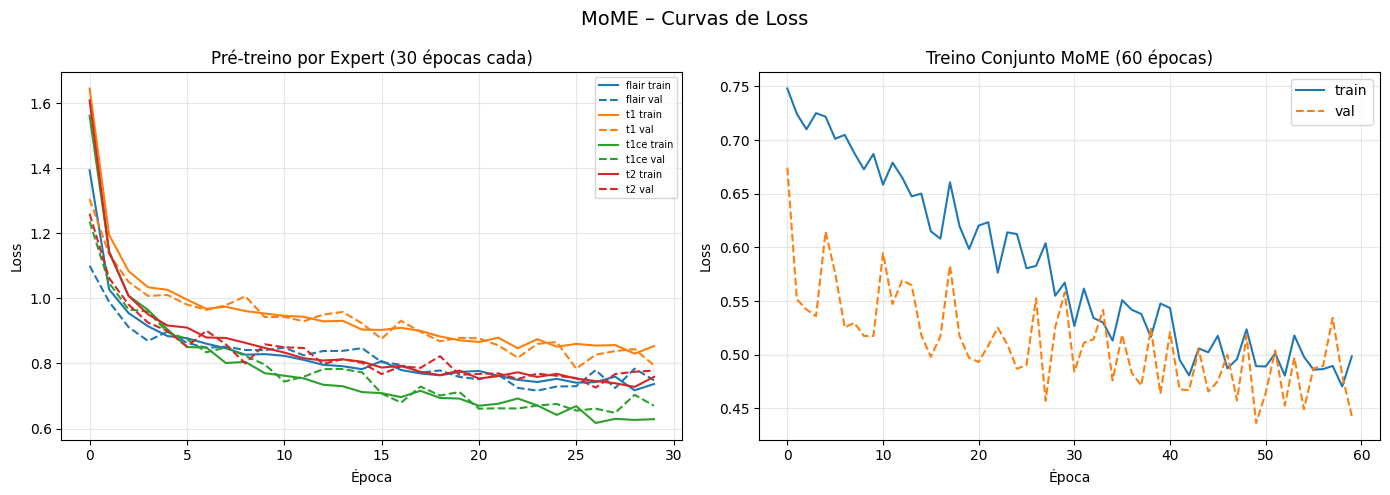

In [19]:
def plot_loss_curves(pretrain_history: dict, joint_history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("MoME – Curvas de Loss", fontsize=14)

    ax = axes[0]
    ax.set_title(f"Pré-treino por Expert ({PRETRAIN_EPOCHS} épocas cada)")
    colors = ["tab:blue","tab:orange","tab:green","tab:red"]
    for (mod, h), c in zip(pretrain_history.items(), colors):
        ax.plot(h["train"], c=c, label=f"{mod} train")
        ax.plot(h["val"],   c=c, ls="--", label=f"{mod} val")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.set_title(f"Treino Conjunto MoME ({JOINT_EPOCHS} épocas)")
    ax.plot(joint_history["train"], label="train")
    ax.plot(joint_history["val"],   ls="--", label="val")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(MOME_LOGS / "loss_curves.png", dpi=150)
    plt.show()


# Curvas de loss
plot_loss_curves(pretrain_hist, joint_hist)


Paciente: BraTS20_Training_228 | split=test | z=62
Dice C1 (necrose):   0.8898
Dice C2 (edema):     0.8791
Dice ET (enhancing): 0.8783
Dice WT:             0.9049
Dice TC:             0.9277


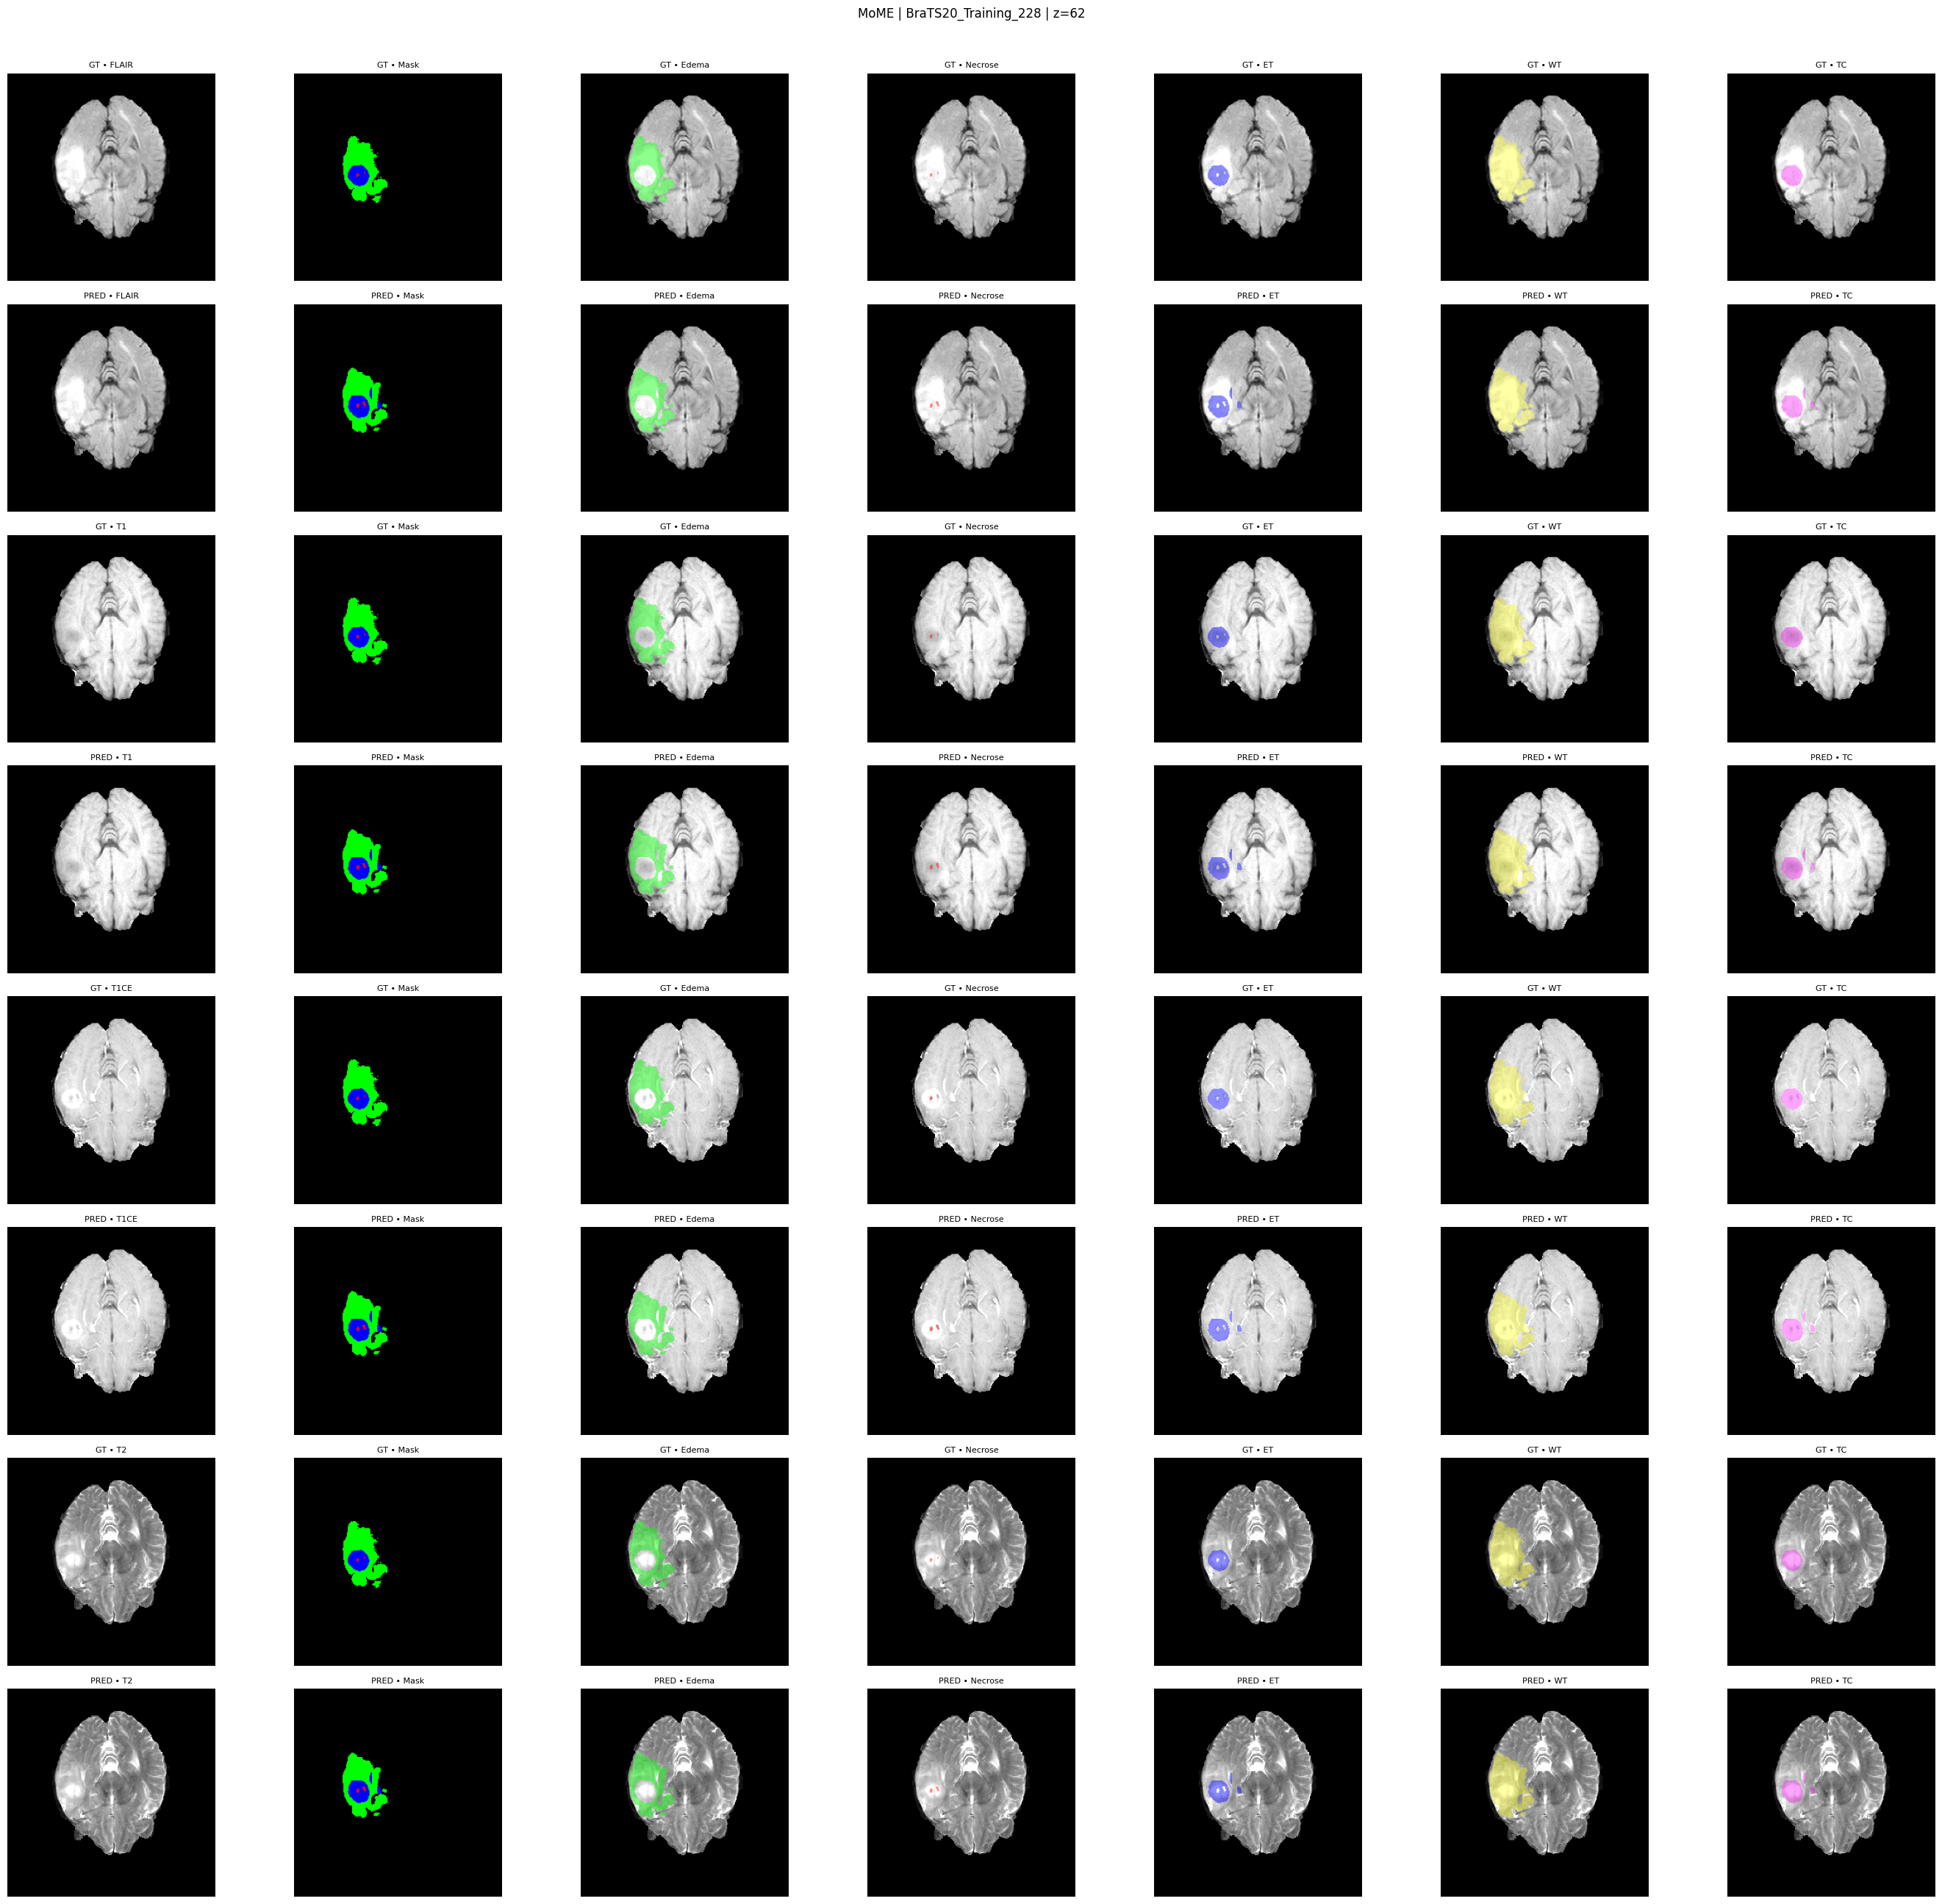

In [20]:
cmap_mask = ListedColormap([
    (0,0,0,1), (1,0,0,1), (0,1,0,1), (0,0,1,1)])
norm_mask = BoundaryNorm([0,1,2,3,4], cmap_mask.N)

def masks_from_seg(seg):
    nec = seg == 1; ede = seg == 2; enh = seg == 3
    wt  = (seg==1)|(seg==2)|(seg==3);  tc  = (seg==1)|(seg==3)
    return nec, ede, enh, wt, tc

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((*mask2d.shape, 4), dtype=np.float32)
    rgba[...,0], rgba[...,1], rgba[...,2] = color_rgb
    rgba[...,3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title, fontsize=8); ax.axis("off")

def plot_random_case_multimodal_gt_pred( 
    ids_list, split_name="test",
    pred_dir=MOME_PRED, seed=None, z=None,
    alpha_cls=0.45, alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))
    d   = case_dir(split_name, cid)

    gt = load_brats_seg(find_file(d, "seg"))
    pr = load_arr(pred_dir / f"{cid}.nii.gz").astype(np.int16)

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice_score(gt==1, pr==1)
    d2 = dice_score(gt==2, pr==2)
    d3 = dice_score(gt==3, pr==3)
    wt = dice_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice_score((gt==1)|(gt==3), (pr==1)|(pr==3))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose):   {d1:.4f}")
    print(f"Dice C2 (edema):     {d2:.4f}")
    print(f"Dice ET (enhancing): {d3:.4f}")
    print(f"Dice WT:             {wt:.4f}")
    print(f"Dice TC:             {tc:.4f}")

    gt2d = gt[:,:,z].T; pr2d = pr[:,:,z].T
    gt_nec,gt_ede,gt_enh,gt_wt,gt_tc = masks_from_seg(gt2d)
    pr_nec,pr_ede,pr_enh,pr_wt,pr_tc = masks_from_seg(pr2d)

    fig, axes = plt.subplots(2*len(MODS), 7,
                             figsize=(28, 3.2*2*len(MODS)))
    fig.suptitle(f"MoME | {cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img2d = norm01(load_arr(find_file(d, mod))[:,:,z]).T
        r_gt, r_pr = 2*i, 2*i+1

        axes[r_gt,0].imshow(img2d,cmap="gray",origin="lower")
        axes[r_gt,0].set_title(f"GT • {mod.upper()}",fontsize=8)
        axes[r_gt,0].axis("off")
        axes[r_gt,1].imshow(gt2d,cmap=cmap_mask,norm=norm_mask,origin="lower")
        axes[r_gt,1].set_title("GT • Mask",fontsize=8); axes[r_gt,1].axis("off")
        overlay(axes[r_gt,2], img2d, gt_ede, (0,1,0), alpha_cls, "GT • Edema")
        overlay(axes[r_gt,3], img2d, gt_nec, (1,0,0), alpha_cls, "GT • Necrose")
        overlay(axes[r_gt,4], img2d, gt_enh, (0,0,1), alpha_cls, "GT • ET")
        overlay(axes[r_gt,5], img2d, gt_wt,  (1,1,0), alpha_comp,"GT • WT")
        overlay(axes[r_gt,6], img2d, gt_tc,  (1,0,1), alpha_comp,"GT • TC")

        axes[r_pr,0].imshow(img2d,cmap="gray",origin="lower")
        axes[r_pr,0].set_title(f"PRED • {mod.upper()}",fontsize=8)
        axes[r_pr,0].axis("off")
        axes[r_pr,1].imshow(pr2d,cmap=cmap_mask,norm=norm_mask,origin="lower")
        axes[r_pr,1].set_title("PRED • Mask",fontsize=8); axes[r_pr,1].axis("off")
        overlay(axes[r_pr,2], img2d, pr_ede, (0,1,0), alpha_cls, "PRED • Edema")
        overlay(axes[r_pr,3], img2d, pr_nec, (1,0,0), alpha_cls, "PRED • Necrose")
        overlay(axes[r_pr,4], img2d, pr_enh, (0,0,1), alpha_cls, "PRED • ET")
        overlay(axes[r_pr,5], img2d, pr_wt,  (1,1,0), alpha_comp,"PRED • WT")
        overlay(axes[r_pr,6], img2d, pr_tc,  (1,0,1), alpha_comp,"PRED • TC")

    plt.tight_layout(); plt.show()
    return cid, z, {"dice_c1":d1,"dice_c2":d2,"dice_ET":d3,
                    "dice_WT":wt,"dice_TC":tc}


# Visualização qualitativa
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(
    test_ids, split_name="test",
    pred_dir=MOME_PRED, seed=None
)